<a href="https://colab.research.google.com/github/nhanmai001-ct1/TH_DeepLearning/blob/main/2001230598_MaiNguyenHoangNhan_TH_Buoi_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from keras.datasets import mnist
from keras.utils import to_categorical
from keras import models
from keras import layers
import keras
import numpy as np

from tensorflow.keras import regularizers


In [ ]:
(x_train, _y_train), (x_test, _) = mnist.load_data()
x_train = x_train.astype ('float32')/255
x_test = x_test.astype ('float32')/255
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


In [ ]:
encoding_dim = 32

input_img = keras.Input(shape=(784,))

encoded = layers.Dense(encoding_dim,
                       activity_regularizer=regularizers.l1(10e-5),
                       activation='relu')(input_img)

encoded = layers.Dense(encoding_dim, activation='relu')(input_img)

decoded = layers.Dense(784, activation='sigmoid')(encoded)

autoencoder = keras.Model(input_img, decoded)

encoder = keras.Model(input_img, encoded)

encoded_input = keras.Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

In [ ]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy',metrics = ['accuracy'])
autoencoder.fit(x_train, x_train,
                epochs=200,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.0118 - loss: 0.2835 - val_accuracy: 0.0133 - val_loss: 0.1970
Epoch 2/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0113 - loss: 0.1737 - val_accuracy: 0.0109 - val_loss: 0.1551
Epoch 3/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0100 - loss: 0.1455 - val_accuracy: 0.0104 - val_loss: 0.1336
Epoch 4/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.0105 - loss: 0.1281 - val_accuracy: 0.0096 - val_loss: 0.1208
Epoch 5/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0106 - loss: 0.1179 - val_accuracy: 0.0103 - val_loss: 0.1126
Epoch 6/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0115 - loss: 0.1108 - val_accuracy: 0.0121 - val_loss: 0.1067
Epoch 7/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0127 - loss: 0.1057 - val_accuracy: 0.0121 - val_loss: 0.1028
Epoch 8/200
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.0127 - loss: 0.1023 - 

In [ ]:
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


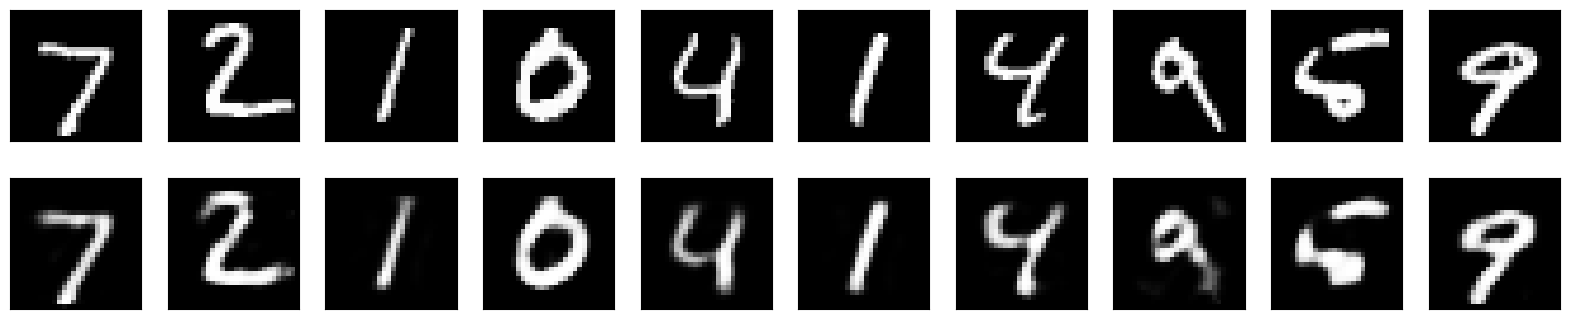

In [ ]:
import matplotlib.pyplot as plt

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()